In [19]:
#!/usr/bin/env python3
import os
import re
import numpy as np
import pandas as pd

# === Configuration ===
# BASE_PATH = "/home/boat/proxyISP/DGC-Net/proxydgc_eval_CMAES_train_lowlight_maxstd0.1_csadampfac1.5"  # Update if needed
# BASE_PATH = "/home/boat/proxyISP/DGC-Net/proxydgc_eval_CMAES_train_sunlit_maxstd0.01_csadampfac10.0"
# BASE_PATH="/home/boat/proxyISP/DGC-Net/proxydgc_eval"
BASE_PATH="/home/boat/proxyISP/DGC-Net/proxydgc_eval_FIXZEROGRADBUG_CFANORMALIZE_train_v16.2-chroma-HumanTunedInitialHype_lowlight_pooled480x640_allHomoRepeatedRaw_standardize_lr0.0005_gradac32"
DIR_PATTERN = re.compile(
    # r"eval_sl_FIXZEROGRADBUG_CFANORMALIZE_train_v16.2-chroma-HumanTunedInitialHype_sunlit_pooled480x640_allHomoRepeatedRaw_standardize_lr0.0005_gradac32_(\d+)_HpatchesV4.1"
    r"eval_ll_FIXZEROGRADBUG_CFANORMALIZE_train_v16.2-chroma-HumanTunedInitialHype_lowlight_pooled480x640_allHomoRepeatedRaw_standardize_lr0.0005_gradac32_(\d+)_HpatchesV4.1",
    # r"eval_*"
    # r"eval_ll_CMAES_lowlight_maxstd0.1_CSA1.5_noiseaug0.6_(\d+)_HpatchesV4.1"
    # r"eval_sl_CMAES_sunlit_maxstd0.01_CSA10.0_noiseaug0.6_(\d+)_HpatchesV4.1"
)
AEPE_FILENAME = "aepe.npy"
NUM_VIEWPOINTS = 5

def load_aepe(filepath):
    """Load AEPE values from .npy or raw file."""
    try:
        return np.load(filepath, allow_pickle=True)
    except Exception:
        with open(filepath, "r") as f:
            content = f.read()
        arr_str = re.findall(r"[\d\.eE\+\-]+", content)
        return np.array([float(x) for x in arr_str])

# === Step 1: Find matching evaluation directories ===
eval_dirs = []
for name in os.listdir(BASE_PATH):
    full_path = os.path.join(BASE_PATH, name)
    # print(full_path)
    if os.path.isdir(full_path):
        match = DIR_PATTERN.match(name)
        if match:
            iter_num = int(match.group(1))
            eval_dirs.append((iter_num, full_path))

if not eval_dirs:
    print("❌ No matching eval directories found.")
    
eval_dirs.sort(key=lambda x: x[0])

# === Step 2: Gather AEPE values ===
rows = []
for iter_num, dir_path in eval_dirs:
    aepe_path = os.path.join(dir_path, AEPE_FILENAME)
    if os.path.exists(aepe_path):
        data = load_aepe(aepe_path)
        if len(data) == NUM_VIEWPOINTS:
            rows.append({
                "iter": iter_num,
                "dir_name": os.path.basename(dir_path)[-20:],
                "avg_aepe": np.mean(data),
                **{f"v{i+1}": data[i] for i in range(NUM_VIEWPOINTS)}
            })
        else:
            print(f"[WARN] Skipping {dir_path}: expected {NUM_VIEWPOINTS} values, got {len(data)}")
    else:
        print(f"[WARN] {AEPE_FILENAME} not found in {dir_path}")

if not rows:
    print("❌ No valid AEPE data found.")

# === Step 3: Create and sort table ===
df = pd.DataFrame(rows)
df_sorted = df.sort_values(by="avg_aepe", ascending=True)

# === Step 4: Display results ===
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", None)  # Show all rows
print("\n🟢 Sorted AEPE results (ascending avg_aepe):")
df_sorted.to_string(index=False)
df_sorted




🟢 Sorted AEPE results (ascending avg_aepe):


,iter,dir_name,avg_aepe,v1,v2,v3,v4,v5
123,123000,_123000_HpatchesV4.1,8.461779,1.877875,2.408504,4.629421,10.158018,23.235075
107,107000,_107000_HpatchesV4.1,8.520962,1.682038,2.524744,4.662042,10.203414,23.532569
115,115000,_115000_HpatchesV4.1,8.532726,1.766975,2.514663,4.744243,10.250666,23.387085
94,94000,2_94000_HpatchesV4.1,8.538901,1.720151,2.517352,4.717318,10.185743,23.553943
104,104000,_104000_HpatchesV4.1,8.539117,1.703162,2.499955,4.747980,10.197253,23.547236
95,95000,2_95000_HpatchesV4.1,8.542220,1.709198,2.474699,4.696927,10.230631,23.599646
116,116000,_116000_HpatchesV4.1,8.543169,1.772249,2.523391,4.694396,10.309694,23.416115
105,105000,_105000_HpatchesV4.1,8.549746,1.698581,2.512408,4.743240,10.234008,23.560493
119,119000,_119000_HpatchesV4.1,8.551326,1.804469,2.492902,4.687113,10.315002,23.457147
108,108000,_108000_HpatchesV4.1,8.556208,1.730925,2.549582,4.677942,10.215828,23.606761


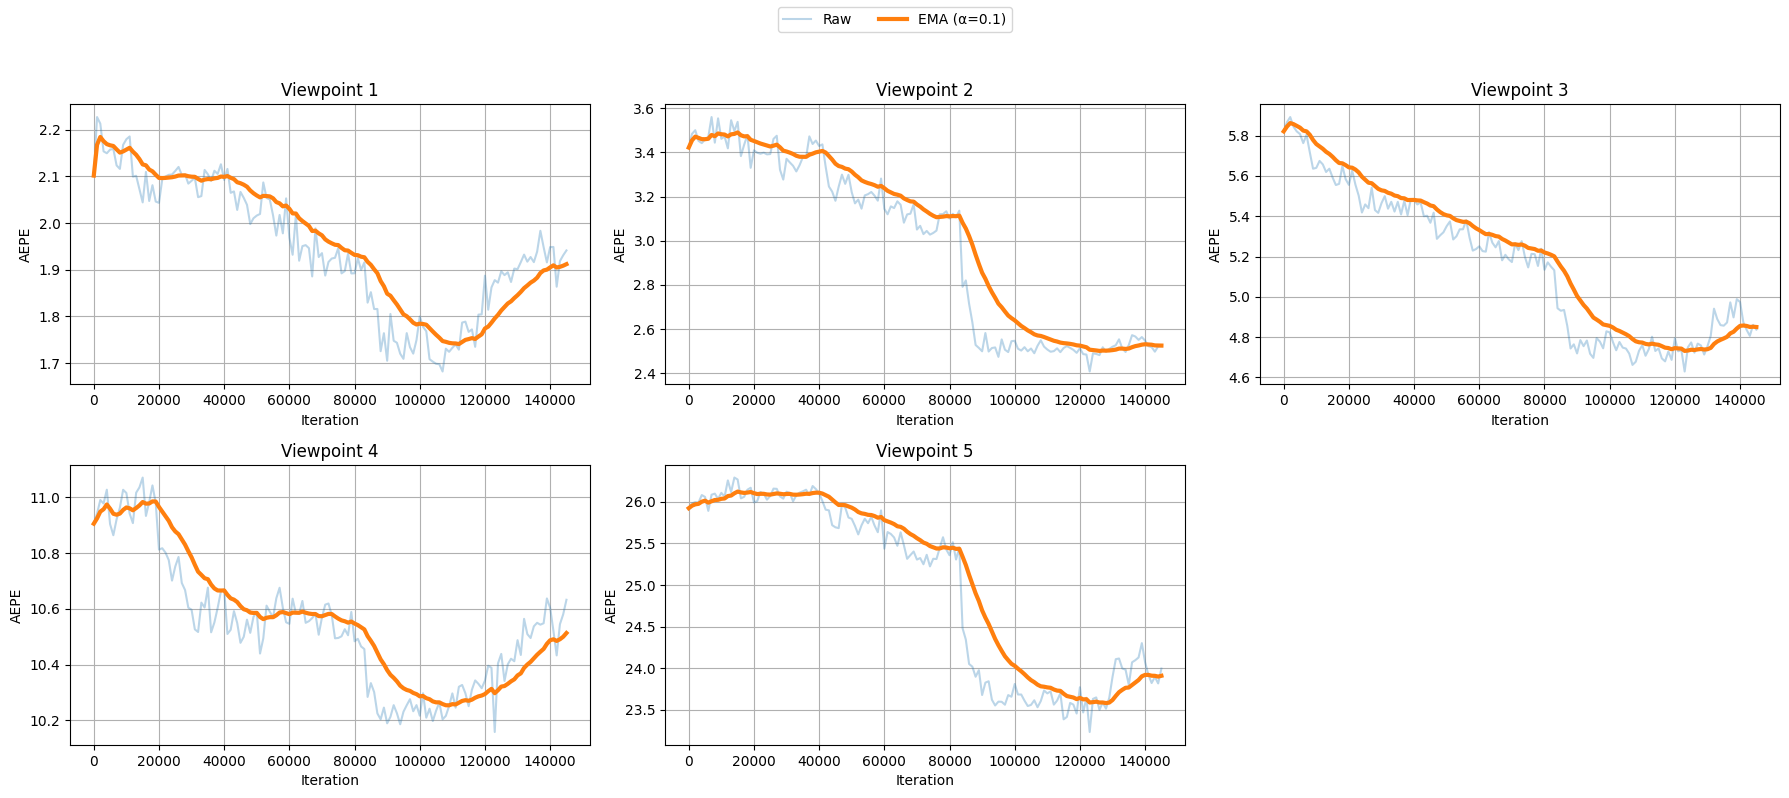

In [20]:
import matplotlib.pyplot as plt

alpha = 0.10

nrows = 2
ncols = 3   # 5 plots → 2x3 with one empty

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(18, 8),
    sharey=False
)

axes = axes.flatten()

for i in range(NUM_VIEWPOINTS):
    ax = axes[i]
    col = f"v{i+1}"

    ema = (
        df[col]
        .ewm(alpha=alpha)
        .mean()
    )

    ax.plot(
        df["iter"],
        df[col],
        alpha=0.3,
        label="Raw"
    )

    ax.plot(
        df["iter"],
        ema,
        linewidth=3,
        label=f"EMA (α={alpha})"
    )

    ax.set_title(f"Viewpoint {i+1}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("AEPE")
    ax.grid(True)

# Hide unused subplot(s)
for j in range(NUM_VIEWPOINTS, len(axes)):
    axes[j].axis("off")

# Single legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2
)

plt.tight_layout(rect=[0, 0, 1, 0.92])

# Save
fig.savefig(
    "ema_all_viewpoints_std0.1damp1.5_2x2_plus1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
#!/usr/bin/env python3
import os
import re
import numpy as np
import pandas as pd

# === Configuration ===
BASE_PATH = "/home/boat/proxyISP/DGC-Net/proxydgc_eval_CMAES_train_lowlight_maxstd0.1_csadampfac1.5"  # Update if needed
# BASE_PATH = "/home/boat/proxyISP/DGC-Net/proxydgc_eval_CMAES_train_sunlit_maxstd0.01_csadampfac10.0"
# BASE_PATH="/home/boat/proxyISP/DGC-Net/proxydgc_eval"
# BASE_PATH="/home/boat/proxyISP/DGC-Net/proxydgc_eval_FIXZEROGRADBUG_CFANORMALIZE_train_v16.2-chroma-HumanTunedInitialHype_lowlight_pooled480x640_allHomoRepeatedRaw_standardize_lr0.0005_gradac32"
DIR_PATTERN = re.compile(
    # r"eval_sl_FIXZEROGRADBUG_CFANORMALIZE_train_v16.2-chroma-HumanTunedInitialHype_sunlit_pooled480x640_allHomoRepeatedRaw_standardize_lr0.0005_gradac32_(\d+)_HpatchesV4.1"
    # r"eval_ll_FIXZEROGRADBUG_CFANORMALIZE_train_v16.2-chroma-HumanTunedInitialHype_lowlight_pooled480x640_allHomoRepeatedRaw_standardize_lr0.0005_gradac32_(\d+)_HpatchesV4.1",
    # r"eval_*"
    r"eval_ll_CMAES_lowlight_maxstd0.1_CSA1.5_noiseaug0.6_(\d+)_HpatchesV4.1"
    # r"eval_sl_CMAES_sunlit_maxstd0.01_CSA10.0_noiseaug0.6_(\d+)_HpatchesV4.1"
)
AEPE_FILENAME = "aepe.npy"
NUM_VIEWPOINTS = 5

def load_aepe(filepath):
    """Load AEPE values from .npy or raw file."""
    try:
        return np.load(filepath, allow_pickle=True)
    except Exception:
        with open(filepath, "r") as f:
            content = f.read()
        arr_str = re.findall(r"[\d\.eE\+\-]+", content)
        return np.array([float(x) for x in arr_str])

# === Step 1: Find matching evaluation directories ===
eval_dirs = []
for name in os.listdir(BASE_PATH):
    full_path = os.path.join(BASE_PATH, name)
    # print(full_path)
    if os.path.isdir(full_path):
        match = DIR_PATTERN.match(name)
        if match:
            iter_num = int(match.group(1))
            eval_dirs.append((iter_num, full_path))

if not eval_dirs:
    print("❌ No matching eval directories found.")
    
eval_dirs.sort(key=lambda x: x[0])

# === Step 2: Gather AEPE values ===
rows = []
for iter_num, dir_path in eval_dirs:
    aepe_path = os.path.join(dir_path, AEPE_FILENAME)
    if os.path.exists(aepe_path):
        data = load_aepe(aepe_path)
        if len(data) == NUM_VIEWPOINTS:
            rows.append({
                "iter": iter_num,
                "dir_name": os.path.basename(dir_path)[-20:],
                "avg_aepe": np.mean(data),
                **{f"v{i+1}": data[i] for i in range(NUM_VIEWPOINTS)}
            })
        else:
            print(f"[WARN] Skipping {dir_path}: expected {NUM_VIEWPOINTS} values, got {len(data)}")
    else:
        print(f"[WARN] {AEPE_FILENAME} not found in {dir_path}")

if not rows:
    print("❌ No valid AEPE data found.")

# === Step 3: Create and sort table ===
df = pd.DataFrame(rows)
df_sorted = df.sort_values(by="avg_aepe", ascending=True)

# === Step 4: Display results ===
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", None)  # Show all rows
print("\n🟢 Sorted AEPE results (ascending avg_aepe):")
df_sorted.to_string(index=False)
df_sorted




🟢 Sorted AEPE results (ascending avg_aepe):


,iter,dir_name,avg_aepe,v1,v2,v3,v4,v5
15,750,0.6_750_HpatchesV4.1,8.165636,1.792476,2.556679,4.671924,10.118430,21.688670
14,700,0.6_700_HpatchesV4.1,8.399468,1.971341,2.693415,5.112797,10.006982,22.212806
58,2900,.6_2900_HpatchesV4.1,8.737262,2.008061,2.868550,5.095470,10.707028,23.007199
55,2750,.6_2750_HpatchesV4.1,8.819302,2.130621,3.126481,5.363616,10.809177,22.666615
56,2800,.6_2800_HpatchesV4.1,8.909879,2.303280,3.295268,5.470830,10.913361,22.566653
57,2850,.6_2850_HpatchesV4.1,8.985425,2.481118,3.464522,6.080783,10.249295,22.651406
54,2700,.6_2700_HpatchesV4.1,9.098419,1.912362,3.314378,5.489571,11.375171,23.400612
10,500,0.6_500_HpatchesV4.1,9.264537,2.406643,3.179374,5.887820,10.668448,24.180402
53,2650,.6_2650_HpatchesV4.1,9.334766,2.166629,3.116207,5.651798,11.448032,24.291165
12,600,0.6_600_HpatchesV4.1,9.470405,2.247307,3.461069,5.680748,11.150496,24.812405
